In [1]:
# Add relevant Jupyter notebook extensions

# Simulate closed-loop
After implementing your control functionality, you can simulate the closed-loop with code that looks something like this...

In [2]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
ROOT = Path.cwd()          # this is notebooks/
REPO = ROOT.parent         # repo root
print("Notebook cwd:", ROOT)
print("Repo root:", REPO)


Notebook cwd: /Users/ninamarcjasz/b1-coding-practical-mt25/notebooks
Repo root: /Users/ninamarcjasz/b1-coding-practical-mt25


In [3]:
# Make the repo root importable
from pathlib import Path
import sys

ROOT = Path.cwd()        # notebooks/
REPO = ROOT.parent       # repo root
sys.path.insert(0, str(REPO))  # ensure repo root is on sys.path

print("Repo on sys.path?", str(REPO) in sys.path)
print("Looking for package here:", REPO / "uuv_mission")


Repo on sys.path? True
Looking for package here: /Users/ninamarcjasz/b1-coding-practical-mt25/uuv_mission


In [4]:
from uuv_mission.dynamic import Submarine, ClosedLoop, Mission   # not "luv.mission"
from uuv_mission.control import PD


In [5]:
# Load mission from CSV
from pathlib import Path

# csv_path as Path works with pandas; convert to string only if necessary
csv_path = REPO / "data" / "mission.csv"
mission = Mission.from_csv(csv_path)
len(mission.reference), len(mission.cave_height), len(mission.cave_depth)


(100, 100, 100)

In [6]:
sub = Submarine()
controller = PD(kp=0.15, kd=0.6)
closed_loop = ClosedLoop(sub, controller)


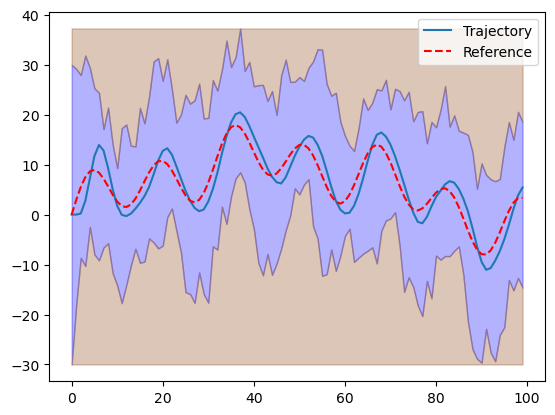

In [7]:
trajectory = closed_loop.simulate_with_random_disturbances(mission, variance=0.2)
trajectory.plot_completed_mission(mission)
